For second part we need RDKit and a conda env

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('BACE1_bioactivity_curated_data.csv')
df

,canonical_smiles,molecule_chembl_id,standard_value,value,class
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.0,413.000,active
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,2.0,0.002,active
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,460.0,0.460,active
3,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...,CHEMBL114147,9000.0,9.000,intermediate
4,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...,CHEMBL419949,5600.0,5.600,intermediate
...,...,...,...,...,...
8810,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1,CHEMBL6172404,2800.0,2.800,intermediate
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,600.0,0.600,active
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,250.0,0.250,active
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19600.0,19.600,inactive


In [3]:
df_no_smiles = df.drop(columns=['canonical_smiles'])

In [4]:
smiles =[]
for i in df.canonical_smiles.tolist():
   compund= str(i).split('.')
   compund_longest = max(compund, key=len)
   smiles.append(compund_longest)

smiles = pd.DataFrame(smiles, columns=['canonical_smiles'])
    

In [5]:
df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,value,class,canonical_smiles
0,CHEMBL406146,413.0,413.000,active,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...
1,CHEMBL78946,2.0,0.002,active,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...
2,CHEMBL324109,460.0,0.460,active,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...
3,CHEMBL114147,9000.0,9.000,intermediate,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...
4,CHEMBL419949,5600.0,5.600,intermediate,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...
...,...,...,...,...,...
8810,CHEMBL6172404,2800.0,2.800,intermediate,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1
8811,CHEMBL6165462,600.0,0.600,active,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O
8812,CHEMBL6161637,250.0,0.250,active,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1
8813,CHEMBL6188525,19600.0,19.600,inactive,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...


Calculate Lipinski descriptors
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.
The Lipinski's Rule stated the following:

1. Molecular weight < 500 Dalton
2. Octanol-water partition coefficient (LogP) < 5
3. Hydrogen bond donors < 5
4. Hydrogen bond acceptors < 10


In [6]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [ ]:
#  using vstack 
#  def lipinski(smiles, verbose=False):

#     moldata =[]
#     for elem in smiles:
#         mol = Chem.MolFromSmiles(elem)
#         moldata.append(mol)

#     basedata = np.empty((1,4))
#     i = 0
#     for mol in moldata:
#         desc_MolWt = Descriptors.MolWt(mol)
#         desc_MolLogP = Descriptors.MolLogP(mol)
#         desc_NumHDonors = Lipinski.NumHDonors(mol)
#         desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

#         row = np.array([desc_MolWt,
#                         desc_MolLogP,
#                         desc_NumHDonors,
#                         desc_NumHAcceptors])
#         if i == 0:
#             basedata = row
#         else:
#             basedata = np.vstack([basedata, row])
#         i = i+1
#     columnnames = ["MolWt", "MolLogP", "NumHDonors", "NumHAcceptors"]
#     descriptors = pd.DataFrame(data=basedata, columns=columnnames)

#     return descriptors


In [7]:
# simple without vstack
def lipinski_descriptors(smiles):
  rows =[]
  for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    rows.append({
      "MolWt": Descriptors.MolWt(mol),
      'MolLogP': Descriptors.MolLogP(mol),
      'NumHDonors': Lipinski.NumHDonors(mol),
      'NumHAcceptors': Lipinski.NumHAcceptors(mol)
    })

  return pd.DataFrame(rows)
  

In [8]:
df_lipinski = lipinski_descriptors(df_clean_smiles.canonical_smiles)
df_lipinski

,MolWt,MolLogP,NumHDonors,NumHAcceptors
0,999.085,-1.43550,13,13
1,893.005,-1.73610,12,12
2,751.988,2.35350,8,9
3,737.895,1.96260,8,8
4,828.020,3.57390,8,8
...,...,...,...,...
8810,317.732,2.28550,1,5
8811,305.721,2.21310,2,5
8812,417.340,4.79760,1,5
8813,453.454,4.30840,1,7


In [10]:
# Combine the lipinski descriptors with the original dataframe
df

,canonical_smiles,molecule_chembl_id,standard_value,value,class
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.0,413.000,active
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,2.0,0.002,active
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,460.0,0.460,active
3,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...,CHEMBL114147,9000.0,9.000,intermediate
4,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...,CHEMBL419949,5600.0,5.600,intermediate
...,...,...,...,...,...
8810,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1,CHEMBL6172404,2800.0,2.800,intermediate
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,600.0,0.600,active
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,250.0,0.250,active
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19600.0,19.600,inactive


In [11]:
df_combined = pd.concat([df,df_lipinski], axis = 1)

In [12]:
df_combined

,canonical_smiles,molecule_chembl_id,standard_value,value,class,MolWt,MolLogP,NumHDonors,NumHAcceptors
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.0,413.000,active,999.085,-1.43550,13,13
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,2.0,0.002,active,893.005,-1.73610,12,12
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,460.0,0.460,active,751.988,2.35350,8,9
3,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...,CHEMBL114147,9000.0,9.000,intermediate,737.895,1.96260,8,8
4,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...,CHEMBL419949,5600.0,5.600,intermediate,828.020,3.57390,8,8
...,...,...,...,...,...,...,...,...,...
8810,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1,CHEMBL6172404,2800.0,2.800,intermediate,317.732,2.28550,1,5
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,600.0,0.600,active,305.721,2.21310,2,5
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,250.0,0.250,active,417.340,4.79760,1,5
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19600.0,19.600,inactive,453.454,4.30840,1,7


In [13]:
df_combined.standard_value.describe()

count    8.815000e+03
mean     7.179609e+05
std      2.610061e+07
min      2.000000e-04
25%      2.200000e+01
50%      1.900000e+02
75%      2.610000e+03
max      1.000000e+09
Name: standard_value, dtype: float64

In [14]:
-np.log10((10**-9)* 100000000 )

np.float64(1.0)

In [15]:
-np.log10((10**-9)* 10000000000)

np.float64(-1.0)

Convert IC50 to pIC50
To allow IC50 data to be more uniformly distributed, we will convert IC50 to the negative logarithmic scale which is essentially -log10(IC50).

This custom function pIC50() will accept a DataFrame as input and will:

Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10
Take the molar value and apply -log10
Delete the standard_value column and create a new pIC50 column

In [16]:
def norm_value(input):
  norm = []
  for i in input['standard_value']:
    if i > 100000000:
      i = 100000000
    norm.append(i)
  input['standard_value_norm'] = norm
  x = input.drop(['standard_value'], axis =1)

  return x

In [17]:
def pIC50(input):
  pIC50 = []

  for i in input['standard_value_norm']:
    molar = i *(10**-9) #converts nM to M
    pIC50.append(-np.log10(molar))

  input['pIC50'] = pIC50
  x = input.drop(['standard_value_norm'], axis=1)

  return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [18]:
df_norm = norm_value(df_combined)
df_norm

,canonical_smiles,molecule_chembl_id,value,class,MolWt,MolLogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.000,active,999.085,-1.43550,13,13,413.0
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,0.002,active,893.005,-1.73610,12,12,2.0
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,0.460,active,751.988,2.35350,8,9,460.0
3,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...,CHEMBL114147,9.000,intermediate,737.895,1.96260,8,8,9000.0
4,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...,CHEMBL419949,5.600,intermediate,828.020,3.57390,8,8,5600.0
...,...,...,...,...,...,...,...,...,...
8810,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1,CHEMBL6172404,2.800,intermediate,317.732,2.28550,1,5,2800.0
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,0.600,active,305.721,2.21310,2,5,600.0
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,0.250,active,417.340,4.79760,1,5,250.0
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19.600,inactive,453.454,4.30840,1,7,19600.0


In [19]:
df_final = pIC50(df_norm)
df_final

,canonical_smiles,molecule_chembl_id,value,class,MolWt,MolLogP,NumHDonors,NumHAcceptors,pIC50
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.000,active,999.085,-1.43550,13,13,6.384050
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,0.002,active,893.005,-1.73610,12,12,8.698970
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,0.460,active,751.988,2.35350,8,9,6.337242
3,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...,CHEMBL114147,9.000,intermediate,737.895,1.96260,8,8,5.045757
4,CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...,CHEMBL419949,5.600,intermediate,828.020,3.57390,8,8,5.251812
...,...,...,...,...,...,...,...,...,...
8810,COC(=O)c1ccc(/C=N/NC(=O)c2ccc(Cl)nc2)cc1,CHEMBL6172404,2.800,intermediate,317.732,2.28550,1,5,5.552842
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,0.600,active,305.721,2.21310,2,5,6.221849
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,0.250,active,417.340,4.79760,1,5,6.602060
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19.600,inactive,453.454,4.30840,1,7,4.707744


In [20]:
df_final.pIC50.describe()

count    8815.000000
mean        6.579602
std         1.416684
min         1.000000
25%         5.583359
50%         6.721246
75%         7.657577
max        12.698970
Name: pIC50, dtype: float64

In [21]:
# We will removing the intermediate class from our dataset
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,canonical_smiles,molecule_chembl_id,value,class,MolWt,MolLogP,NumHDonors,NumHAcceptors,pIC50
0,CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...,CHEMBL406146,413.000,active,999.085,-1.43550,13,13,6.384050
1,CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...,CHEMBL78946,0.002,active,893.005,-1.73610,12,12,8.698970
2,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL324109,0.460,active,751.988,2.35350,8,9,6.337242
5,CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...,CHEMBL116826,34.000,inactive,767.987,1.36900,8,9,4.468521
6,CC(C)[C@H](NC(=O)C[C@H](O)[C@H](Cc1cc(F)cc(F)c...,CHEMBL143239,0.020,active,717.722,4.31960,7,7,7.698970
...,...,...,...,...,...,...,...,...,...
8809,CCOc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6173905,0.700,active,319.748,2.60320,2,5,6.154902
8811,COc1cc(/C=N/NC(=O)c2ccc(Cl)nc2)ccc1O,CHEMBL6165462,0.600,active,305.721,2.21310,2,5,6.221849
8812,Clc1ccc(-c2nnc(CNC3CCN(Cc4ccccc4)CC3)o2)c(Cl)c1,CHEMBL6161637,0.250,active,417.340,4.79760,1,5,6.602060
8813,Nc1c2c(nc3c1C(c1cccc([N+](=O)[O-])c1)C1=C(O3)C...,CHEMBL6188525,19.600,inactive,453.454,4.30840,1,7,4.707744


In [22]:
df_2class.to_csv('BACE1_bioactivity_data_pIC50.csv')


Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors

In [ ]:
%pip install seaborn

In [23]:
import seaborn as sns
sns.set(style = 'ticks')
import matplotlib.pyplot as plt


C:\Users\anuja\AppData\Local\Temp\ipykernel_30268\1555363096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data= df_2class, edgecolor='black',palette='Set2')


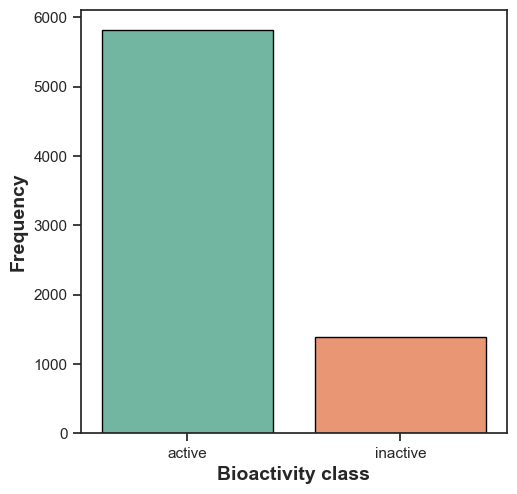

In [24]:
plt.figure(figsize=(5.5,5.5))

sns.countplot(x='class', data= df_2class, edgecolor='black',palette='Set2')

plt.xlabel('Bioactivity class', fontsize= 14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

Scatter plot of MW versus LogP


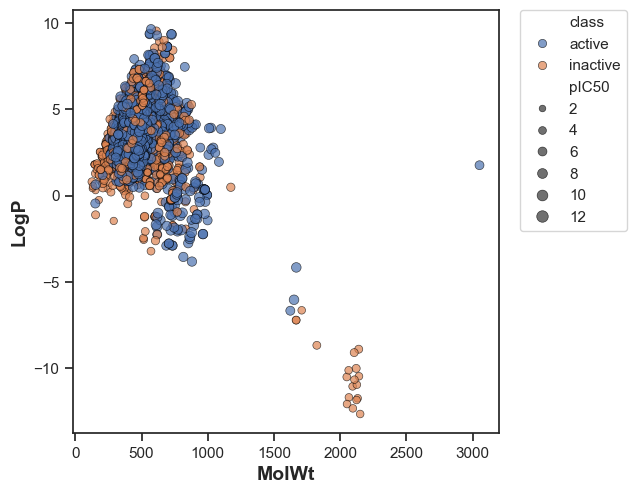

In [25]:
plt.figure(figsize=(5.5,5.5))

sns.scatterplot(x = 'MolWt', y = 'MolLogP', data = df_2class, hue ='class', size ='pIC50', edgecolor='black', alpha = 0.7)

plt.xlabel('MolWt', fontsize = 14, fontweight = 'bold')
plt.ylabel('LogP', fontsize =14, fontweight = 'bold')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0)
plt.savefig('plot_MW_vs_LogP.pdf')

Box plots

C:\Users\anuja\AppData\Local\Temp\ipykernel_30268\2932491069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y ='pIC50', data= df_2class, palette='Set2')


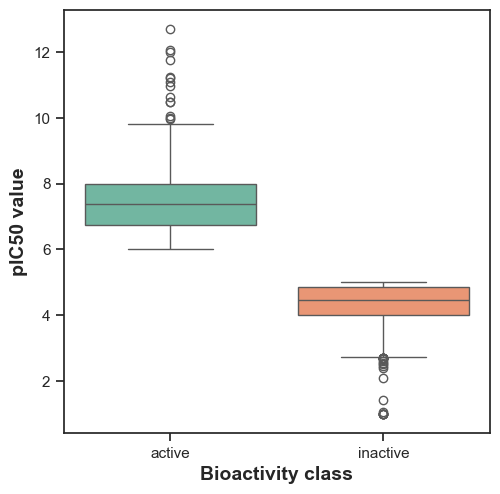

In [26]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y ='pIC50', data= df_2class, palette='Set2')

plt.xlabel('Bioactivity class', fontsize = 14, fontweight='bold')
plt.ylabel('pIC50 value',fontsize=14, fontweight= 'bold')

plt.savefig('plot_ic50.pdf')

Statistical analysis | Mann-Whitney U Test

In [27]:
from scipy.stats import mannwhitneyu
def mannwhitney(descriptor,  verbos = False):
  
  # actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active =df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive =df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

  # compare the samples
  stat, p = mannwhitneyu(active,inactive)
  print('Statistics = %.3f, p = %.3e' % (stat,p))

  # interpret
  alpha = 0.05 #it is the statistical significance
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({
    'Descriptor' : descriptor,
    'Statistics' : stat,
    'p' : p,
    'alpha' : alpha,
    'Interpretation' : interpretation}, index = [0])

  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [28]:
mannwhitney('pIC50')

Statistics = 8057930.000, p = 0.000e+00


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,8057930.0,0.0,0.05,Different distribution (reject H0)


C:\Users\anuja\AppData\Local\Temp\ipykernel_30268\3935144917.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x ='class', y = 'MolWt', data = df_2class, palette='Set1')


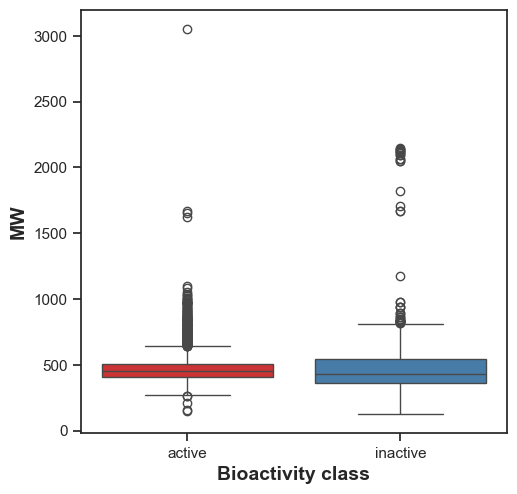

In [29]:
# Box plot of MolWt
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x ='class', y = 'MolWt', data = df_2class, palette='Set1')

plt.xlabel('Bioactivity class', fontsize = 14, fontweight ='bold')
plt.ylabel('MW', fontsize =14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [30]:
mannwhitney('MolWt')

Statistics = 4496002.000, p = 1.881e-11


,Descriptor,Statistics,p,alpha,Interpretation
0,MolWt,4496002.0,1.881292e-11,0.05,Different distribution (reject H0)


C:\Users\anuja\AppData\Local\Temp\ipykernel_30268\3087578720.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'class', y ='MolLogP', data = df_2class, palette='Set1')


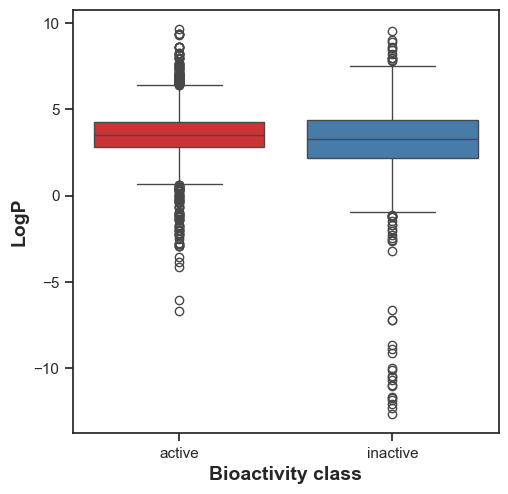

In [31]:
# LogP
plt.figure(figsize=(5.5,5.5))

sns.boxplot(x= 'class', y ='MolLogP', data = df_2class, palette='Set1')

plt.xlabel('Bioactivity class', fontsize = 14, fontweight='bold')
plt.ylabel('LogP', fontsize = 14, fontweight = 'bold')

plt.savefig('plot_Log.pdf')

In [32]:
mannwhitney('MolLogP')

Statistics = 4453457.000, p = 1.039e-09


,Descriptor,Statistics,p,alpha,Interpretation
0,MolLogP,4453457.0,1.039343e-09,0.05,Different distribution (reject H0)


C:\Users\anuja\AppData\Local\Temp\ipykernel_30268\1777166288.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'class', y ='NumHAcceptors', data=df_2class, palette='Set1')


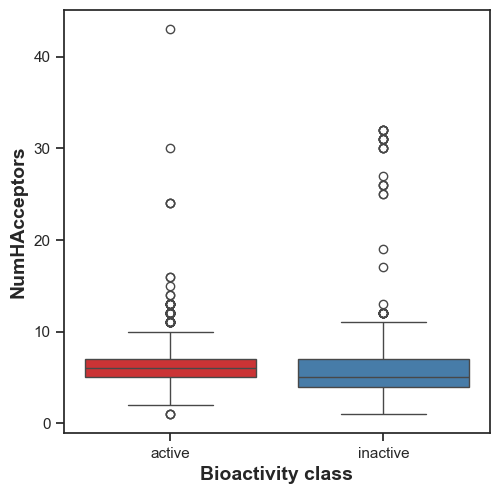

In [33]:
# NumHAcceptors

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x= 'class', y ='NumHAcceptors', data=df_2class, palette='Set1')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [34]:
mannwhitney('NumHAcceptors')

Statistics = 4693423.000, p = 2.546e-22


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,4693423.0,2.546117e-22,0.05,Different distribution (reject H0)


Interpretation of Statistical Results
Taking look at pIC50 values, the actives and inactives displayed statistically significant diffrence, which is to be expected since threshold values
(IC50 <1,000nM = Actives while IC50 > 10,000nM = Inactives, corresponding to pIC50 > 6 Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

Lipinski's descriptors
All of the 4 Lipinski's descriptors exhibited statistically significant difference between the actives and inactives.

In [35]:
# Zip files
import zipfile
import glob

with zipfile.ZipFile('results.zip', 'w',compression=zipfile.ZIP_DEFLATED) as zipf:
  for file in glob.glob('*.csv *.pdf'):
    zipf.write(file)

In [36]:
!dir

 Volume in drive D is New Volume
 Volume Serial Number is 9444-9510

 Directory of d:\project msc 2\QSAR\AChE

05-08-2026  18:51    <DIR>          .
03-08-2026  08:18    <DIR>          ..
04-08-2026  11:10           469,818 BACE1.zip
04-08-2026  11:01           818,648 BACE1_activities_cleaned.csv
04-08-2026  11:01         1,265,201 BACE1_activities_raw.csv
04-08-2026  11:02           892,723 BACE1_bioactivity_curated_data.csv
05-08-2026  18:51         1,125,211 BACE1_bioactivity_data_pIC50.csv
04-08-2026  11:18            35,097 BACE1_data_curation_part _1.ipynb
05-08-2026  18:59           286,747 BACE1_Exploratory_analysis_part2.ipynb
05-08-2026  18:53               131 mannwhitneyu_MolLogP.csv
05-08-2026  18:53               129 mannwhitneyu_MolWt.csv
05-08-2026  18:53               137 mannwhitneyu_NumHAcceptors.csv
05-08-2026  18:53               110 mannwhitneyu_pIC50.csv
05-08-2026  18:40           165,131 Part 3_BACE1_Descriptor_Dataset.ipynb
05-08-2026  18:52            15,663